# LightGBM Regressor

Train tu 2020-01-01 den het 2025, tune bang GridSearchCV + TimeSeriesSplit, va test tu 2026-01-01 den ngay hien tai co trong dataset.

In [1]:
from pathlib import Path
import json
import math
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from lightgbm import LGBMRegressor

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'Notebooks' else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.aq_course_ml.config import (
    CATEGORICAL_COLUMNS,
    FEATURE_COLUMNS,
    MODEL_DIR,
    PROCESSED_DATA_PATH,
    RANDOM_STATE,
    RAIN_ALERT_THRESHOLD_MM,
    REGRESSION_TARGET,
    REPORT_DIR,
)
from src.aq_course_ml.train_model import build_preprocessor

TRAIN_START = '2020-01-01'
TRAIN_END = '2025-12-31 23:59:59'
TEST_START = '2026-01-01'
MODEL_NAME = 'LightGBM Regressor'
MODEL_FILE = MODEL_DIR / 'lightgbm_regressor.joblib'
METRICS_FILE = REPORT_DIR / 'lightgbm_metrics.json'
PLOT_FILE = REPORT_DIR / 'lightgbm_predictions.png'
PARAM_GRID = {'model__n_estimators': [200, 400], 'model__num_leaves': [31, 63], 'model__learning_rate': [0.03, 0.05], 'model__subsample': [0.8, 1.0], 'model__colsample_bytree': [0.8, 1.0]}
TRAIN_LIMIT = None


## Load Data And Date Split

Split theo thoi gian, khong shuffle.

In [2]:
df = pd.read_csv(PROCESSED_DATA_PATH, parse_dates=['timestamp'])
train_df = df[(df['timestamp'] >= TRAIN_START) & (df['timestamp'] <= TRAIN_END)].copy()
test_df = df[df['timestamp'] >= TEST_START].copy()

print('Rows:', {'total': len(df), 'train': len(train_df), 'test': len(test_df)})
print('Train:', train_df['timestamp'].min(), '->', train_df['timestamp'].max())
print('Test:', test_df['timestamp'].min(), '->', test_df['timestamp'].max())

if train_df.empty or test_df.empty:
    raise ValueError('Train/test split is empty. Crawl data from 2020-01-01 through the current date first.')

x_train = train_df[FEATURE_COLUMNS + CATEGORICAL_COLUMNS]
y_train = train_df[REGRESSION_TARGET]
x_test = test_df[FEATURE_COLUMNS + CATEGORICAL_COLUMNS]
y_test = test_df[REGRESSION_TARGET]

if TRAIN_LIMIT is not None and len(train_df) > TRAIN_LIMIT:
    step = max(1, len(train_df) // TRAIN_LIMIT)
    search_df = train_df.iloc[::step].tail(TRAIN_LIMIT).copy()
else:
    search_df = train_df

x_train_search = search_df[FEATURE_COLUMNS + CATEGORICAL_COLUMNS]
y_train_search = search_df[REGRESSION_TARGET]
print('Rows used for grid search:', len(search_df))


Rows: {'total': 56094, 'train': 52596, 'test': 3498}
Train: 2020-01-01 12:00:00 -> 2025-12-31 23:00:00
Test: 2026-01-01 00:00:00 -> 2026-05-26 17:00:00
Rows used for grid search: 52596


## Grid Search With TimeSeriesSplit

In [3]:
base_pipeline = Pipeline([
    ('preprocess', build_preprocessor()),
    ('model', LGBMRegressor(objective='regression', random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)),
])

tscv = TimeSeriesSplit(n_splits=4)
search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=PARAM_GRID,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    n_jobs=1,
    refit=True,
)
search.fit(x_train_search, y_train_search)

best_params = search.best_params_
best_cv_neg_mae = float(search.best_score_)
best_params, best_cv_neg_mae


({'model__colsample_bytree': 0.8,
  'model__learning_rate': 0.03,
  'model__n_estimators': 200,
  'model__num_leaves': 31,
  'model__subsample': 0.8},
 -1.449995972475954)

## Refit Best Model And Test On 2026

In [4]:
model = search.best_estimator_
model.fit(x_train, y_train)
predictions = pd.Series(model.predict(x_test), index=test_df.index).clip(lower=0)

regression_metrics = {
    'mae': float(mean_absolute_error(y_test, predictions)),
    'rmse': float(math.sqrt(mean_squared_error(y_test, predictions))),
    'r2': float(r2_score(y_test, predictions)),
}
regression_metrics


{'mae': 0.8403584649083107,
 'rmse': 2.5631798035743873,
 'r2': 0.31027888209663934}

## Rain Alert Test

In [5]:
alert_predictions = (predictions >= RAIN_ALERT_THRESHOLD_MM).astype(int)
alert_metrics = {
    'accuracy': float(accuracy_score(test_df['target_rain_alert_6h'], alert_predictions)),
    'f1': float(f1_score(test_df['target_rain_alert_6h'], alert_predictions, zero_division=0)),
    'confusion_matrix': confusion_matrix(test_df['target_rain_alert_6h'], alert_predictions, labels=[0, 1]).tolist(),
    'classification_report': classification_report(
        test_df['target_rain_alert_6h'],
        alert_predictions,
        labels=[0, 1],
        zero_division=0,
        output_dict=True,
    ),
}
alert_metrics


{'accuracy': 0.8825042881646655,
 'f1': 0.6183844011142061,
 'confusion_matrix': [[2754, 285], [126, 333]],
 'classification_report': {'0': {'precision': 0.95625,
   'recall': 0.9062191510365252,
   'f1-score': 0.9305625950329448,
   'support': 3039.0},
  '1': {'precision': 0.5388349514563107,
   'recall': 0.7254901960784313,
   'f1-score': 0.6183844011142061,
   'support': 459.0},
  'accuracy': 0.8825042881646655,
  'macro avg': {'precision': 0.7475424757281554,
   'recall': 0.8158546735574783,
   'f1-score': 0.7744734980735755,
   'support': 3498.0},
  'weighted avg': {'precision': 0.901477699462106,
   'recall': 0.8825042881646655,
   'f1-score': 0.889599247117364,
   'support': 3498.0}}}

## Save Model, Metrics, And Plot

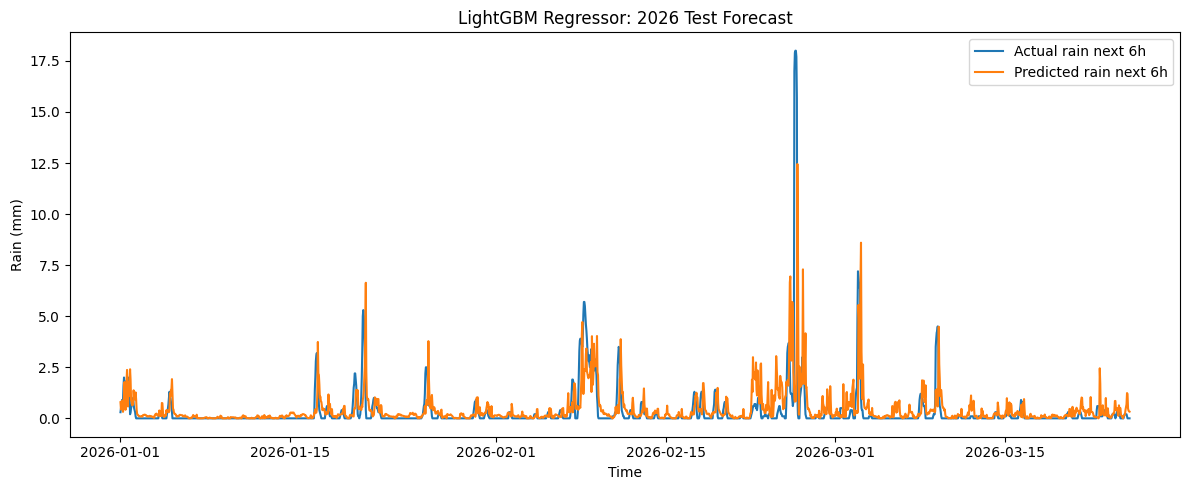

Saved model: D:\air-quality-course-ml\Notebooks\models\lightgbm_regressor.joblib
Saved metrics: D:\air-quality-course-ml\Results\lightgbm_metrics.json
Saved plot: D:\air-quality-course-ml\Results\lightgbm_predictions.png


In [6]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(model, MODEL_FILE)

preview = test_df[['timestamp', REGRESSION_TARGET]].copy()
preview['prediction'] = predictions.values
preview = preview.sort_values('timestamp').head(2000)

plt.figure(figsize=(12, 5))
plt.plot(preview['timestamp'], preview[REGRESSION_TARGET], label='Actual rain next 6h')
plt.plot(preview['timestamp'], preview['prediction'], label='Predicted rain next 6h')
plt.xlabel('Time')
plt.ylabel('Rain (mm)')
plt.title(f'{MODEL_NAME}: 2026 Test Forecast')
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_FILE, dpi=150)
plt.show()

metrics = {
    'model': MODEL_NAME,
    'train_period': ['2020-01-01', '2025-12-31'],
    'test_period': ['2026-01-01', str(test_df['timestamp'].max())],
    'rows': {'total': int(len(df)), 'train': int(len(train_df)), 'test': int(len(test_df))},
    'grid_search_rows': int(len(search_df)),
    'best_params': best_params,
    'best_cv_neg_mae': best_cv_neg_mae,
    'regression': regression_metrics,
    'rain_alert': alert_metrics,
}
METRICS_FILE.write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding='utf-8')

print('Saved model:', MODEL_FILE)
print('Saved metrics:', METRICS_FILE)
print('Saved plot:', PLOT_FILE)
